# Mini Project 2: California Real-Estate Market Regions

**Objective.** Divide the California Housing observations into a small number of market regions that balance geographic proximity with similarity in median house value. The analysis uses only longitude, latitude, and median house value, as required. Each observation is a census block group, not an individual house, and `MedHouseVal` is measured in units of $100,000.

## Methodology

### Purpose and suitability of K-means

K-means is an unsupervised clustering method: it finds groups when the data do not come with known region labels. It is useful here because every block group can be represented by two location coordinates and one price measurement. A cluster center then describes a typical longitude, latitude, and price for one market region. Including both coordinates encourages nearby observations to be grouped, while including price encourages observations with similar values to be grouped.

This method is a practical baseline, but it is important to be precise about what it guarantees. K-means favors compact groups in the three-dimensional feature space; it does **not** impose a formal adjacency constraint. Therefore, it can encourage geographic continuity but cannot guarantee that every cluster is one connected shape. A spatially constrained method would be preferable if strict contiguity were mandatory.

### Data structure

Let there be $n$ block groups. The input is an $n \times 3$ numeric matrix. Row $i$ is

$$x_i=(\text{longitude}_i,\text{latitude}_i,\text{median house value}_i).$$

There is no response variable in this analysis. Unlike linear regression, which predicts an outcome from explanatory variables, K-means treats all three selected columns as coordinates used to define similarity.

### Objective function

For a chosen number of clusters $K$, K-means partitions the observations into non-overlapping sets $C_1,\ldots,C_K$ and assigns each set a centroid $\mu_k$. It minimizes the within-cluster sum of squared Euclidean distances:

$$
\min_{C_1,\ldots,C_K,\,\mu_1,\ldots,\mu_K}
\sum_{k=1}^{K}\sum_{i\in C_k}\lVert z_i-\mu_k\rVert_2^2,
$$

where $z_i$ denotes the standardized version of observation $i$. The criterion rewards clusters whose members lie close to their centroid. Because squared distance is used, unusually distant observations receive extra weight.

### Algorithm

The standard iterative solution is Lloyd's algorithm:

1. Choose $K$ initial centroids. The implementation uses **k-means++**, which spreads the initial centers apart.
2. **Assignment step:** assign every observation to its nearest centroid by Euclidean distance.
3. **Update step:** replace each centroid with the coordinate-wise mean of the observations assigned to it.
4. Repeat steps 2 and 3 until the assignments stop changing or the centroid improvement is smaller than the tolerance (or the iteration limit is reached).

Each step cannot increase the objective, so the algorithm converges, but it may reach a local rather than global minimum. I therefore use 20 different initializations and retain the solution with the smallest objective.

### Hyperparameters and their selection

The central hyperparameter is $K$. I examined $K=2$ through $K=8$ using two diagnostics: inertia (the objective above) and the silhouette coefficient, which compares each point's cohesion within its own cluster to its separation from the nearest other cluster. Inertia always falls as $K$ grows, so its bend is more informative than its absolute value. The final choice is **$K=4$**: it gives a substantial reduction in inertia relative to two or three clusters while keeping the map small enough to interpret as broad market regions. The silhouette scores are reported as a diagnostic rather than treated as the only rule; they favor fewer, coarser groups, while the project goal also requires a useful regional subdivision.

Other settings are `init="k-means++"`, `n_init=20`, and `random_state=42`. Multiple starts reduce sensitivity to an unlucky initialization, and the fixed seed makes the report reproducible. The remaining convergence settings use scikit-learn defaults.

### Why scaling is required

Euclidean distance depends on measurement units. Longitude and latitude are in degrees, whereas median house value is in units of $100,000; their numerical spreads are different and the units are not directly comparable. Without scaling, a feature with greater numerical variation would dominate the distance and therefore the clusters. I standardize each column as

$$z_{ij}=\frac{x_{ij}-\bar{x}_j}{s_j},$$

so each feature has mean 0 and standard deviation 1. This gives longitude, latitude, and price comparable influence. Standardization is a modeling choice—not a statement that one standard deviation has identical practical meaning for all three variables.

## Results

### Final maps

The statewide overview contains every observation in one coordinate system:

![All California block groups colored and shaped by K-means region](figures/california_kmeans_combined.png)

The four panels below separate the same assignments to make geographic overlap easier to inspect:

![Faceted California maps highlighting one K-means region per panel](figures/california_kmeans_regions.png)

The combined plot gives a comprehensive statewide view of all 20,640 assignments, while the faceted plot shows the same four broad combinations of geography and price without allowing overlapping clusters to hide one another. Each panel highlights one region with a distinct color and marker; faint gray points preserve the full statewide context, and the gold star marks that region’s mean longitude and latitude. Panel headings report cluster size and mean house value. Because region numbers are arbitrary in K-means, I relabeled them after fitting in a stable order: southern regions first and, within each broad north/south group, lower mean price before higher mean price.

### Mean price by region

| Region | Broad interpretation | Block groups | Mean `MedHouseVal` | Approx. mean price |
|---:|---|---:|---:|---:|
| 1 | Southern, lower-price | 9,044 | 1.636 | $163,581 |
| 2 | Southern, higher-price | 2,762 | 3.859 | $385,886 |
| 3 | Northern, lower-price | 5,802 | 1.242 | $124,204 |
| 4 | Northern, higher-price | 3,032 | 3.310 | $331,013 |

The two southern clusters have nearly the same average latitude but differ sharply in price; the higher-price cluster concentrates around expensive coastal portions of Southern California. The northern observations show a similar split: the higher-price region is centered nearer the Bay Area/coast, while the lower-price region extends farther inland and north. Thus the solution captures both the broad north–south geography and the coastal/inland price contrast.

These labels describe cluster averages, not every neighborhood. Boundaries are gradual in the original data, some colors may appear as pockets inside another region, and the capped values in this dataset compress differences at the expensive end. The map should therefore be interpreted as an exploratory market segmentation rather than official geographic boundaries or a causal explanation of house prices.

## Conclusion

K-means provides a transparent way to summarize 20,640 block groups with four centroids and an easily interpreted map. Standardization prevents the units of one feature from controlling the answer, and repeated k-means++ starts improve stability. The resulting regions reveal a strong price split within both Southern and Northern California. Its main limitation is that geographic continuity is encouraged through coordinates but not enforced; a spatially constrained clustering method would be the natural next step if connected regions were essential.

## Appendix: Full runnable code

The following single code cell reproduces the data loading, scaling, model-selection diagnostics, final model, summary table, and map.

K-selection diagnostics


,K,Inertia,Silhouette
0,2,26768.4,0.545
1,3,18289.0,0.529
2,4,12109.4,0.490
3,5,9863.6,0.472
4,6,8113.9,0.415
5,7,6563.2,0.410
6,8,5796.4,0.395


Region summary


,Block_groups,Mean_longitude,Mean_latitude,Mean_MedHouseVal,Approx_mean_price_USD
Region,,,,,
1,9044,-117.920,33.918,1.636,163581
2,2762,-118.224,33.895,3.859,385886
3,5802,-121.440,38.117,1.242,124204
4,3032,-122.136,37.569,3.310,331013


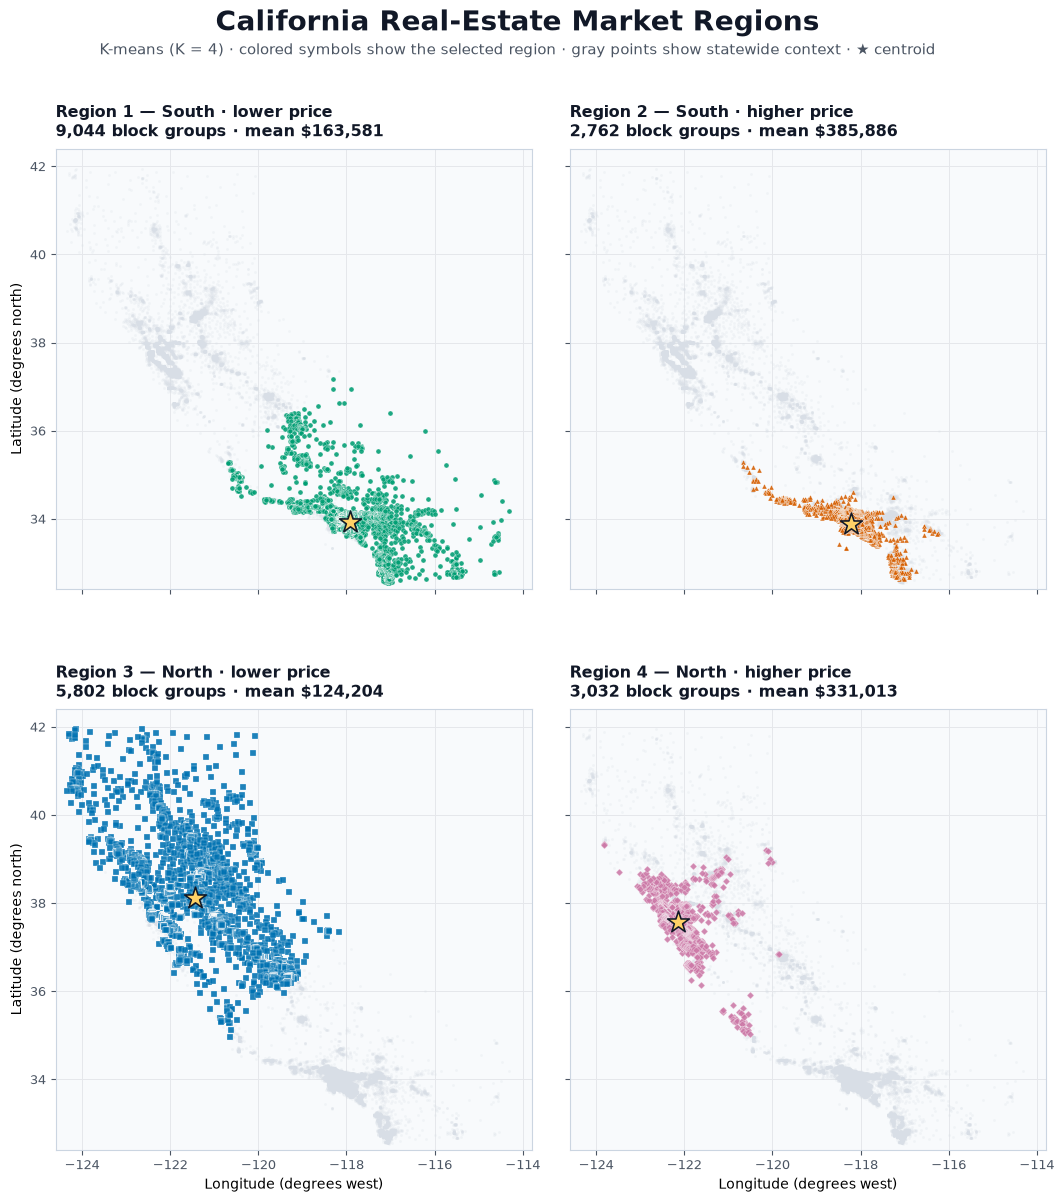

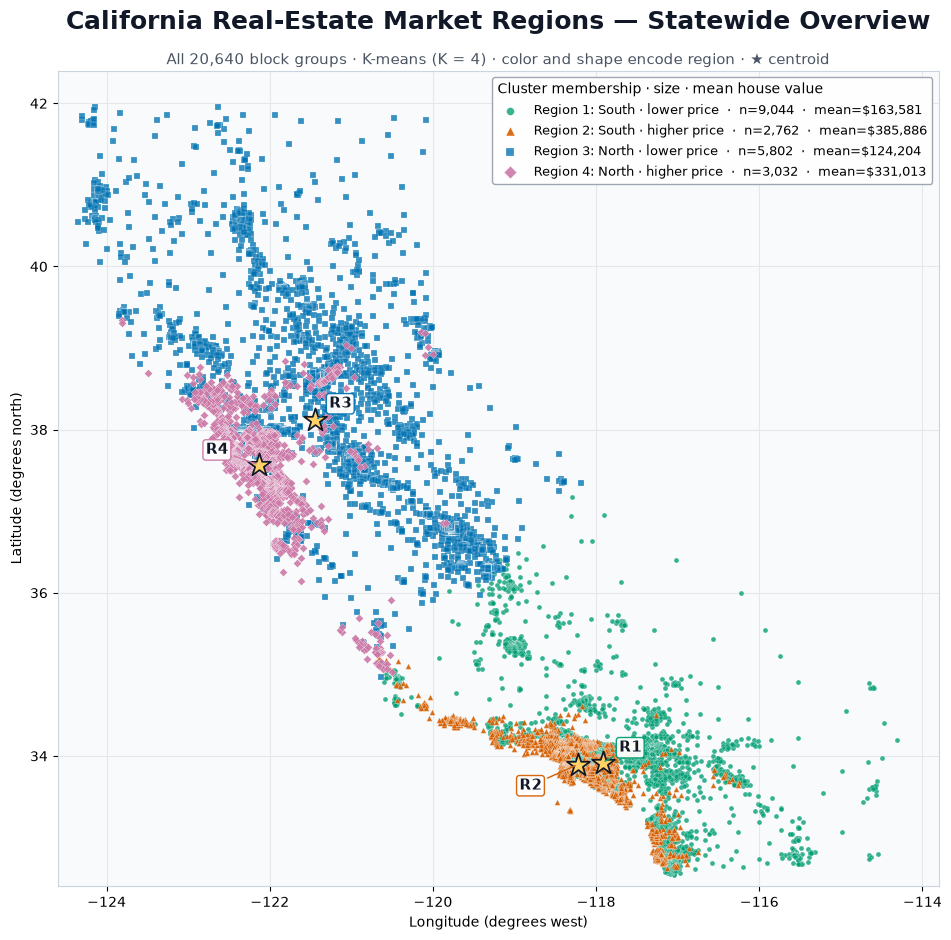

In [1]:
# Appendix: full runnable analysis code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Load the California Housing data.
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

# Use only the three features specified in the assignment.
feature_names = ["Longitude", "Latitude", "MedHouseVal"]
X = df[feature_names].dropna().copy()

# Standardize before computing Euclidean distances.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compare a small, interpretable range of K values.
diagnostics = []
for k in range(2, 9):
    candidate = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42,
    )
    candidate_labels = candidate.fit_predict(X_scaled)
    diagnostics.append(
        {
            "K": k,
            "Inertia": candidate.inertia_,
            # Sampling makes this O(n^2) diagnostic fast and reproducible.
            "Silhouette": silhouette_score(
                X_scaled,
                candidate_labels,
                sample_size=5000,
                random_state=42,
            ),
        }
    )

diagnostics = pd.DataFrame(diagnostics)
print("K-selection diagnostics")
display(diagnostics.round({"Inertia": 1, "Silhouette": 3}))

# Fit the selected four-cluster model.
selected_k = 4
model = KMeans(
    n_clusters=selected_k,
    init="k-means++",
    n_init=20,
    random_state=42,
)
raw_labels = model.fit_predict(X_scaled)

# Relabel for readable, stable reporting: south to north, then low to high price.
centers_original = pd.DataFrame(
    scaler.inverse_transform(model.cluster_centers_),
    columns=feature_names,
)
south = centers_original.nsmallest(2, "Latitude").sort_values("MedHouseVal")
north = centers_original.nlargest(2, "Latitude").sort_values("MedHouseVal")
ordered_raw_labels = list(south.index) + list(north.index)
label_map = {raw_label: region for region, raw_label in enumerate(ordered_raw_labels, 1)}
X["Region"] = pd.Series(raw_labels, index=X.index).map(label_map)

# Report cluster sizes, centers, and mean prices.
region_summary = (
    X.groupby("Region")
    .agg(
        Block_groups=("MedHouseVal", "size"),
        Mean_longitude=("Longitude", "mean"),
        Mean_latitude=("Latitude", "mean"),
        Mean_MedHouseVal=("MedHouseVal", "mean"),
    )
)
region_summary["Approx_mean_price_USD"] = (
    region_summary["Mean_MedHouseVal"] * 100_000
).round().astype(int)
print("Region summary")
display(region_summary.round(3))

# Produce and save the required final map.
region_styles = {
    1: {"name": "South · lower price", "color": "#009E73", "marker": "o"},
    2: {"name": "South · higher price", "color": "#D55E00", "marker": "^"},
    3: {"name": "North · lower price", "color": "#0072B2", "marker": "s"},
    4: {"name": "North · higher price", "color": "#CC79A7", "marker": "D"},
}

# Faceting prevents geographically overlapping price clusters from obscuring
# one another. Every panel uses the same scale and a faint statewide backdrop.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 12.5),
    sharex=True,
    sharey=True,
    facecolor="white",
)

for ax, (region, style) in zip(axes.flat, region_styles.items()):
    subset = X[X["Region"] == region]
    center = region_summary.loc[region]
    mean_price = center["Approx_mean_price_USD"]

    # All observations provide geographic context without competing for color.
    ax.scatter(
        X["Longitude"],
        X["Latitude"],
        s=4,
        c="#D8DEE6",
        alpha=0.24,
        linewidths=0,
        rasterized=True,
        zorder=1,
    )
    ax.scatter(
        subset["Longitude"],
        subset["Latitude"],
        s=13,
        c=style["color"],
        marker=style["marker"],
        alpha=0.88,
        edgecolors="white",
        linewidths=0.22,
        rasterized=True,
        zorder=2,
    )
    ax.scatter(
        center["Mean_longitude"],
        center["Mean_latitude"],
        marker="*",
        s=270,
        c="#FFD166",
        edgecolors="#111827",
        linewidths=1.15,
        zorder=4,
    )
    ax.set_title(
        f"Region {region} — {style['name']}\n"
        f"{int(center['Block_groups']):,} block groups · mean ${mean_price:,.0f}",
        loc="left",
        fontsize=11.5,
        fontweight="bold",
        color="#111827",
        pad=9,
    )
    ax.set_xlim(-124.6, -113.8)
    ax.set_ylim(32.4, 42.4)
    ax.set_aspect("equal", adjustable="box")
    ax.set_facecolor("#F8FAFC")
    ax.grid(color="#E5E7EB", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#4B5563", labelsize=9)
    for spine in ax.spines.values():
        spine.set_color("#CBD5E1")

for ax in axes[:, 0]:
    ax.set_ylabel("Latitude (degrees north)", fontsize=10)
for ax in axes[-1, :]:
    ax.set_xlabel("Longitude (degrees west)", fontsize=10)

fig.suptitle(
    "California Real-Estate Market Regions",
    fontsize=20,
    fontweight="bold",
    color="#111827",
    y=0.982,
)
fig.text(
    0.5,
    0.946,
    "K-means (K = 4) · colored symbols show the selected region · gray points show statewide context · ★ centroid",
    ha="center",
    fontsize=10.5,
    color="#4B5563",
)
fig.subplots_adjust(top=0.875, bottom=0.065, left=0.08, right=0.98, hspace=0.24, wspace=0.08)
figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
figure_path = figure_dir / "california_kmeans_regions.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

# Create a cohesive statewide view containing every cluster. Smaller clusters
# are drawn last so they remain visible where geographic locations overlap.
combined_fig, combined_ax = plt.subplots(figsize=(11.5, 9.5), facecolor="white")
combined_ax.set_facecolor("#F8FAFC")
draw_order = [3, 1, 4, 2]
for region in draw_order:
    style = region_styles[region]
    subset = X[X["Region"] == region]
    summary = region_summary.loc[region]
    combined_ax.scatter(
        subset["Longitude"],
        subset["Latitude"],
        s=13 if region in (1, 3) else 17,
        c=style["color"],
        marker=style["marker"],
        alpha=0.78 if region in (1, 3) else 0.9,
        edgecolors="white",
        linewidths=0.2,
        rasterized=True,
        label=(
            f"Region {region}: {style['name']}  ·  "
            f"n={int(summary['Block_groups']):,}  ·  "
            f"mean=${summary['Approx_mean_price_USD']:,.0f}"
        ),
        zorder=2 + region,
    )

for region, style in region_styles.items():
    center = region_summary.loc[region]
    combined_ax.scatter(
        center["Mean_longitude"],
        center["Mean_latitude"],
        marker="*",
        s=300,
        c="#FFD166",
        edgecolors="#111827",
        linewidths=1.25,
        zorder=10,
    )
    offsets = {1: (12, 8), 2: (-42, -18), 3: (10, 9), 4: (-38, 8)}
    combined_ax.annotate(
        f"R{region}",
        (center["Mean_longitude"], center["Mean_latitude"]),
        xytext=offsets[region],
        textcoords="offset points",
        fontsize=10.5,
        fontweight="bold",
        color="#111827",
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": style["color"], "alpha": 0.95},
        arrowprops={"arrowstyle": "-", "color": style["color"], "lw": 1.0},
        zorder=11,
    )

combined_ax.set(
    xlim=(-124.6, -113.8),
    ylim=(32.4, 42.4),
    xlabel="Longitude (degrees west)",
    ylabel="Latitude (degrees north)",
)
combined_ax.set_aspect("equal", adjustable="box")
combined_ax.grid(color="#E5E7EB", linewidth=0.75)
combined_ax.set_axisbelow(True)
for spine in combined_ax.spines.values():
    spine.set_color("#CBD5E1")
combined_ax.set_title(
    "California Real-Estate Market Regions — Statewide Overview",
    fontsize=18,
    fontweight="bold",
    color="#111827",
    pad=30,
)
combined_ax.text(
    0.5,
    1.008,
    "All 20,640 block groups · K-means (K = 4) · color and shape encode region · ★ centroid",
    transform=combined_ax.transAxes,
    ha="center",
    fontsize=10.5,
    color="#4B5563",
)
handles, labels = combined_ax.get_legend_handles_labels()
order_lookup = {label.split(":", 1)[0]: (handle, label) for handle, label in zip(handles, labels)}
ordered = [order_lookup[f"Region {region}"] for region in range(1, 5)]
legend = combined_ax.legend(
    [item[0] for item in ordered],
    [item[1] for item in ordered],
    title="Cluster membership · size · mean house value",
    loc="upper right",
    frameon=True,
    framealpha=0.97,
    facecolor="white",
    edgecolor="#9CA3AF",
    fontsize=9.3,
    title_fontsize=10,
    markerscale=1.55,
)
legend._legend_box.align = "left"
combined_fig.tight_layout()
combined_path = figure_dir / "california_kmeans_combined.png"
combined_fig.savefig(combined_path, dpi=190, bbox_inches="tight")
plt.show()
